# Business Understanding

## Project Domain

## Problem Statements

## Goals

## Solution Statements

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"andyfermana206","key":"fc80494e02a812df037615cdff406766"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
License(s): copyright-authors


In [4]:
!mkdir stroke-prediction-dataset
!unzip stroke-prediction-dataset.zip -d stroke-prediction-dataset
!ls stroke-prediction-dataset

Archive:  stroke-prediction-dataset.zip
  inflating: stroke-prediction-dataset/healthcare-dataset-stroke-data.csv  
healthcare-dataset-stroke-data.csv


## Import Library yang dibutuhkan

In [471]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
import pickle

In [472]:
df = pd.read_csv('/content/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')

In [473]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [474]:
df.drop(['id', 'ever_married', 'Residence_type', 'avg_glucose_level'],axis=1, inplace = True)

In [475]:
df.head()

,gender,age,hypertension,heart_disease,work_type,bmi,smoking_status,stroke
0,Male,67.0,0,1,Private,36.6,formerly smoked,1
1,Female,61.0,0,0,Self-employed,NaN,never smoked,1
2,Male,80.0,0,1,Private,32.5,never smoked,1
3,Female,49.0,0,0,Private,34.4,smokes,1
4,Female,79.0,1,0,Self-employed,24.0,never smoked,1


In [476]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          5110 non-null   object 
 1   age             5110 non-null   float64
 2   hypertension    5110 non-null   int64  
 3   heart_disease   5110 non-null   int64  
 4   work_type       5110 non-null   object 
 5   bmi             4909 non-null   float64
 6   smoking_status  5110 non-null   object 
 7   stroke          5110 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 319.5+ KB


In [477]:
numerical = []
catgcols =[]
for col in df.columns:
  if df[col].dtype == 'float64':
    numerical.append(col)
  else:
    catgcols.append(col)

for col in df.columns:
  if col in numerical:
    df[col].fillna(df[col].median(), inplace=True)
  else:
    df[col].fillna(df[col].mode()[0], inplace=True)

<ipython-input-477-6261519890f6>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
<ipython-input-477-6261519890f6>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [478]:
numerical

['age', 'bmi']

In [479]:
catgcols

['gender',
 'hypertension',
 'heart_disease',
 'work_type',
 'smoking_status',
 'stroke']

In [480]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [482]:
ind_col = [col for col in df.columns if col != 'stroke']
dep_col = 'stroke'


In [483]:
df[dep_col].value_counts()

,count
stroke,
0,4861
1,249


**Transformasi Dataset**

In [484]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in catgcols:
  df[col] = le.fit_transform(df[col])

In [485]:
df['stroke'] = le.fit_transform(df['stroke'])

In [487]:
x = df[ind_col]
y = df[dep_col]

In [488]:
df.head()

,gender,age,hypertension,heart_disease,work_type,bmi,smoking_status,stroke
0,1,67.0,0,1,2,36.6,1,1
1,0,61.0,0,0,3,28.1,2,1
2,1,80.0,0,1,2,32.5,2,1
3,0,49.0,0,0,2,34.4,3,1
4,0,79.0,1,0,3,24.0,2,1


In [489]:
df.to_csv('modify-strokedata.csv')

In [490]:
features = ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'work_type', 'smoking_status']
target = 'stroke'

In [491]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)

## Exploratory Data Analysis

Text(0, 0.5, 'Jumlah')

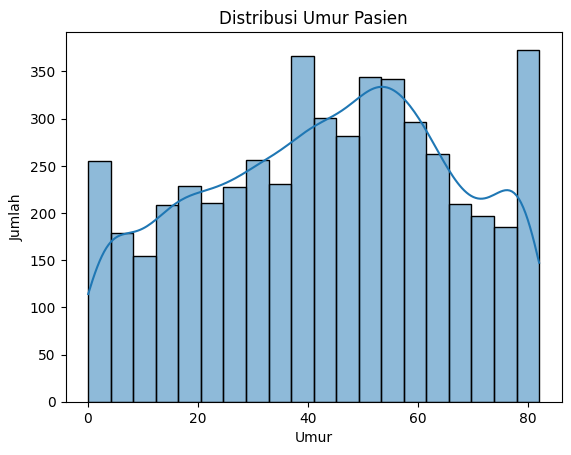

In [492]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribusi Umur Pasien')
plt.xlabel('Umur')
plt.ylabel('Jumlah')

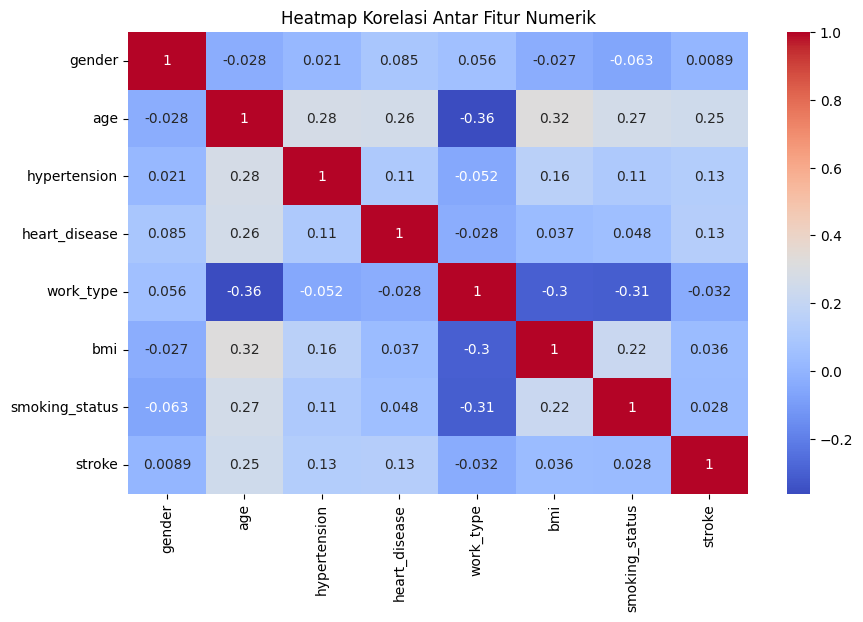

In [493]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

Text(0, 0.5, 'Jumlah')

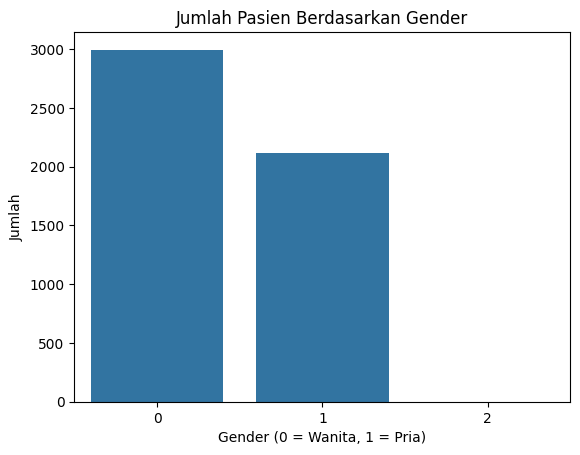

In [494]:
sns.countplot(x='gender', data=df)
plt.title('Jumlah Pasien Berdasarkan Gender')
plt.xlabel('Gender (0 = Wanita, 1 = Pria)')
plt.ylabel('Jumlah')

Text(0, 0.5, 'Jumlah')

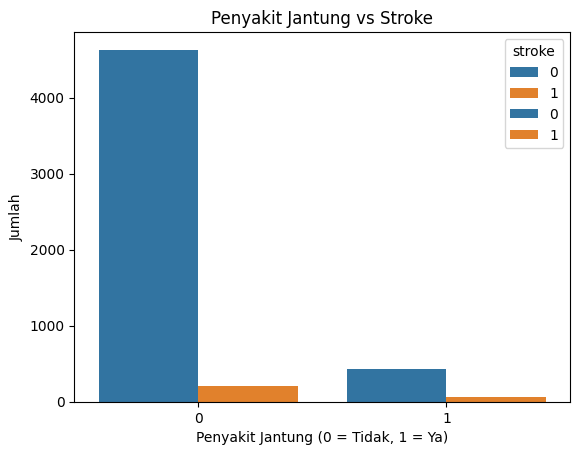

In [495]:
sns.countplot(x='hypertension', hue='stroke', data=df)
plt.title('Hipertensi vs Stroke')
plt.xlabel('Hipertensi (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')

sns.countplot(x='heart_disease', hue='stroke', data=df)
plt.title('Penyakit Jantung vs Stroke')
plt.xlabel('Penyakit Jantung (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')

Text(0, 0.5, 'BMI')

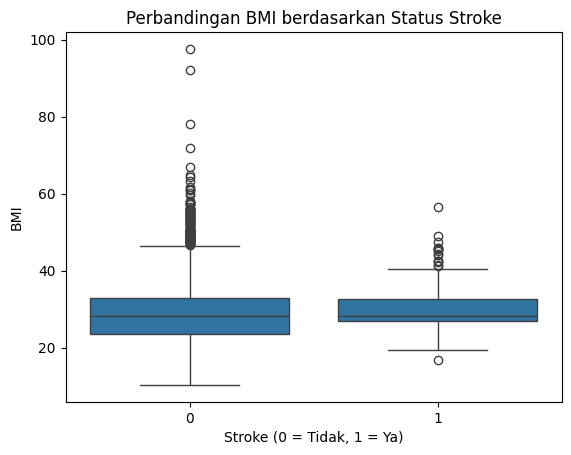

In [496]:
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title('Perbandingan BMI berdasarkan Status Stroke')
plt.xlabel('Stroke (0 = Tidak, 1 = Ya)')
plt.ylabel('BMI')

Text(0, 0.5, 'Jumlah Pasien Stroke')

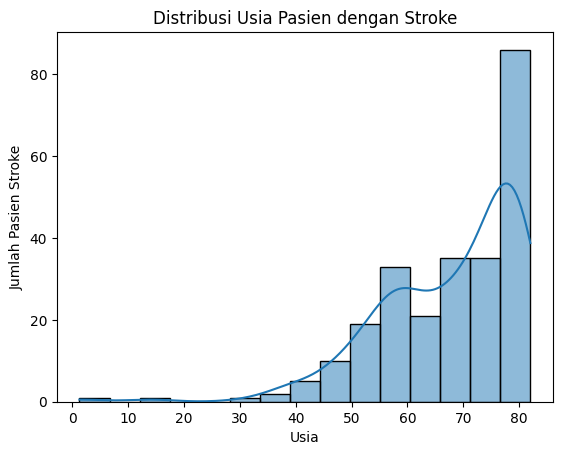

In [497]:
sns.histplot(data=df[df['stroke'] == 1], x='age', bins=15, kde=True)
plt.title('Distribusi Usia Pasien dengan Stroke')
plt.xlabel('Usia')
plt.ylabel('Jumlah Pasien Stroke')

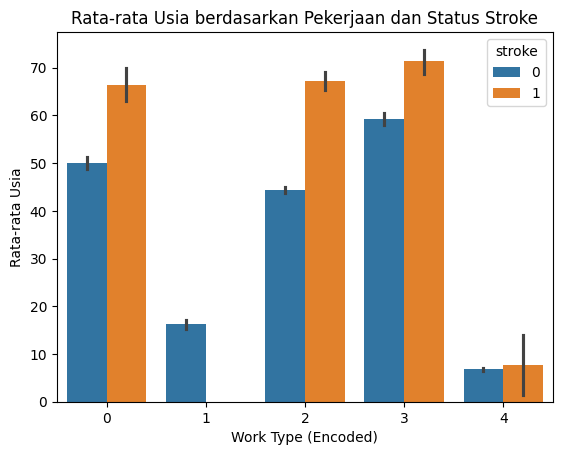

In [498]:
sns.barplot(x='work_type', y='age', hue='stroke', data=df)
plt.title('Rata-rata Usia berdasarkan Pekerjaan dan Status Stroke')
plt.xlabel('Work Type (Encoded)')
plt.ylabel('Rata-rata Usia')
plt.show()

# Data Preparation

In [499]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

In [500]:
# Cek nilai kosong
print(df.isnull().sum(1))

# Isi nilai kosong pada kolom BMI dengan median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

0       0
1       0
2       0
3       0
4       0
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Length: 5110, dtype: int64


<ipython-input-500-cd5a17342ced>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [501]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

In [502]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age', 'bmi']] = scaler.fit_transform(df[['age', 'bmi']])

In [503]:
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 75, 100],
                         labels=['<30', '30-45', '45-60', '60-75', '75+'])

# Modeling

In [504]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    Dense(128, activation="relu"),
    Dense(23, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(len(le.classes_), activation="softmax")
])

In [505]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [506]:
X = df[['gender', 'age', 'hypertension', 'heart_disease', 'bmi']]
y = df['stroke']

In [507]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [508]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [509]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_76 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 23)             │         2,967 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,609 (45.35 KB)

 Trainable params: 11,609 (45.35 KB)

 Non-trainable params: 0 (0.00 B)

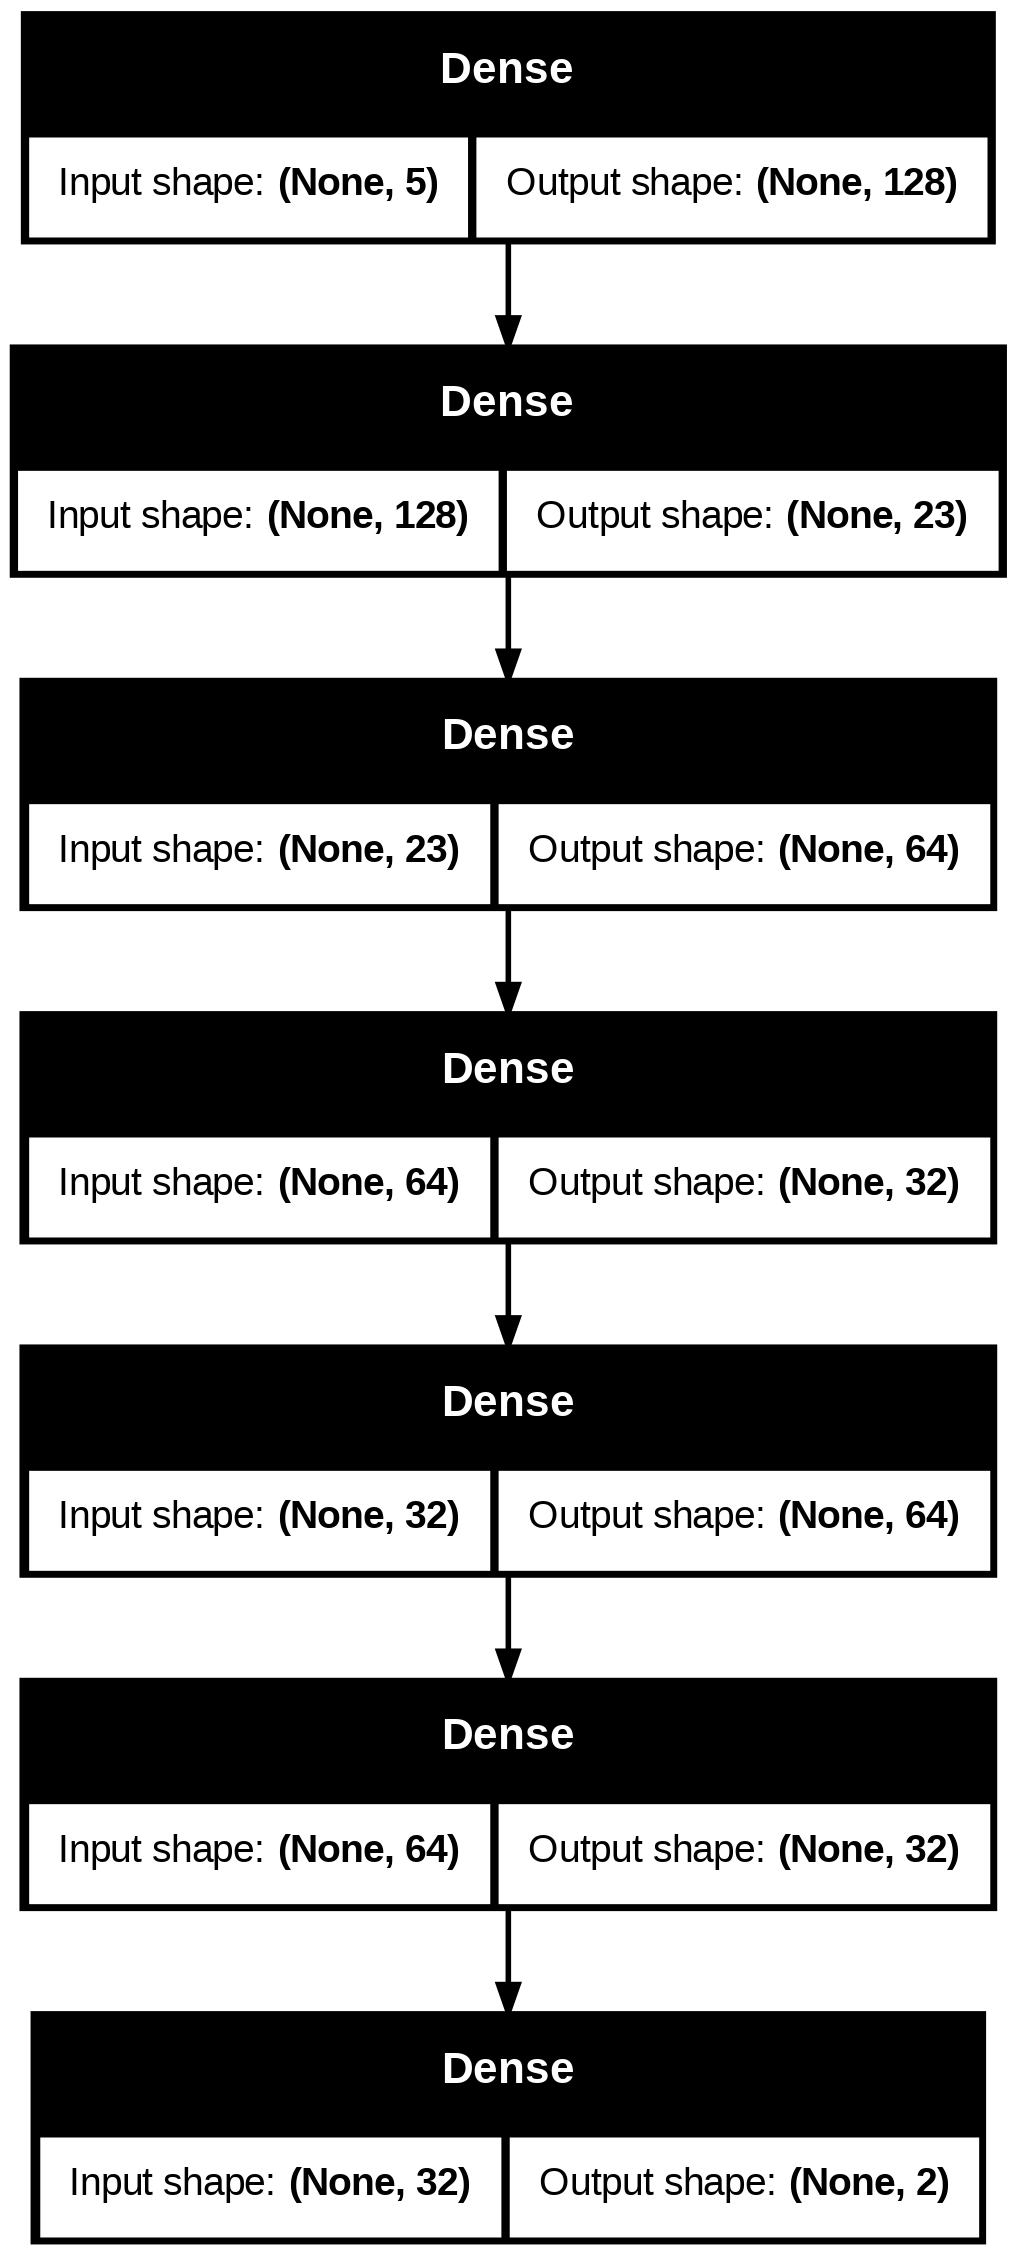

In [510]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [511]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))


Epoch 1/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9484 - loss: nan - val_accuracy: 0.9511 - val_loss: nan
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9482 - loss: nan - val_accuracy: 0.9511 - val_loss: nan
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9566 - loss: nan - val_accuracy: 0.9511 - val_loss: nan
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9468 - loss: nan - val_accuracy: 0.9511 - val_loss: nan
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9574 - loss: nan - val_accuracy: 0.9511 - val_loss: nan
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9515 - loss: nan - val_accuracy: 0.9511 - val_loss: nan
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9520 - loss: nan - val_accuracy: 0.9511 - val_loss: nan
Epoch 8/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9497 - loss: nan - val_accuracy: 0.9511 - val_loss: nan
Epoch 9/50
256/256 ━━━━━

# Evaluation

In [512]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9555 - loss: nan
Akurasi Model: 0.9511
Loss Model: nan


In [513]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'akurasi y: {test_acc*100:.2f}%')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9555 - loss: nan 
akurasi y: 95.11%


# Deployment

## Model Simulation

## Save Model

In [466]:

import pickle
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [355]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('stroke.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpa9mrrf35'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  132962125028752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125029520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125030096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125030672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125029904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125031440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125030864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125032208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125031632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125032976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132962125032400: Tens